# **Project Name**    - Tesla Stock Price Prediction



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/ Sita


# **Project Summary -**

This project aims to predict Tesla's stock closing prices using Deep Learning techniques, specifically Simple Recurrent Neural Networks (SimpleRNN) and Long Short-Term Memory (LSTM) networks. Stock market data is sequential in nature, where historical prices influence future movements. Traditional machine learning models often struggle to capture such temporal dependencies, making recurrent neural networks a suitable choice for time-series forecasting.

The project involves data preprocessing, handling missing values, exploratory data analysis, feature engineering, and normalization of stock prices. Historical Tesla stock data is transformed into time-series sequences and used to train both SimpleRNN and LSTM models. The models are evaluated using performance metrics such as Mean Squared Error (MSE), and their predictive capabilities are compared for 1-day, 5-day, and 10-day stock price forecasting.

The objective is to identify which deep learning architecture better captures stock market trends and can provide more accurate predictions. The project also demonstrates the practical application of deep learning in financial forecasting and decision-making systems.


# **GitHub Link -**

https://github.com/maha2806/Tesla-Stock-Price-Prediction-Deep-Learning.git

# **Problem Statement**


Tesla stock prices change over time.

Past prices influence future prices.

Therefore we use Deep Learning models
that can learn sequential patterns.



# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















## ***1. Know Your Data***

### Import Libraries

In [7]:
!pip install keras-tuner

In [8]:
import keras_tuner as kt

In [9]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
df = pd.read_csv('/content/drive/MyDrive/Labmentix_projects/DAY_2/TSLA.csv')

### Dataset First View

In [12]:
# Dataset First Look

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [13]:
# Dataset Rows & Columns Count

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2416
Number of Columns : 7


### Dataset Information

In [14]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


#### Duplicate Values

In [15]:
# Duplicate Values

duplicate_count = df.duplicated().sum()

print("Duplicate Rows :", duplicate_count)

Duplicate Rows : 0


#### Missing Values/Null Values

In [16]:
# Missing Values/Null Values

df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


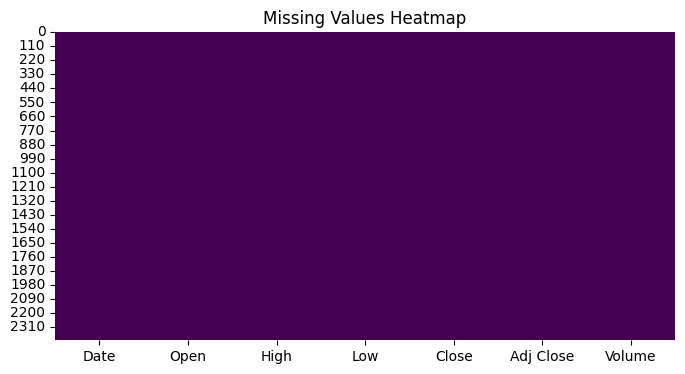

In [17]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The Tesla stock dataset contains historical stock market information, including Date, Open, High, Low, Close, Adj Close, and Volume. Each row represents the trading activity of Tesla stock for a specific day.

During the initial data exploration, the dataset structure, dimensions, data types, missing values, and duplicate records were analyzed. The dataset was found to contain no duplicate rows, ensuring that each observation is unique. The Date column represents the trading date, while the price-related columns describe Tesla's stock performance throughout the trading session. The Volume column indicates the number of shares traded on a given day.

Since the objective of this project is stock price forecasting, the Close price will be used as the primary target variable for prediction. The dataset is sequential in nature, making it suitable for time-series forecasting using deep learning models such as SimpleRNN and LSTM.


## ***2. Understanding Your Variables***

In [18]:
# Dataset Columns

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [19]:
# Dataset Columns

list(df.columns)

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

In [20]:
# Dataset Describe

df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Variables Description

The dataset contains seven variables that describe Tesla's daily stock market performance.

1. Date – Represents the trading date.
2. Open – Stock price at the beginning of the trading session.
3. High – Highest stock price reached during the trading day.
4. Low – Lowest stock price recorded during the trading day.
5. Close – Stock price at the end of the trading session. This is the primary target variable used for prediction.
6. Adj Close – Adjusted closing price that accounts for corporate actions such as stock splits and dividends.
7. Volume – Total number of shares traded during the day.

The dataset contains both temporal information (Date) and numerical financial indicators (Open, High, Low, Close, Adj Close, and Volume). Since the objective of the project is stock price forecasting, the Close price will be used as the target variable for training the deep learning models.


### Check Unique Values for each variable.

In [21]:
# Check Unique Values for each Variable

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Date: 2416 unique values
Open: 2132 unique values
High: 2128 unique values
Low: 2136 unique values
Close: 2225 unique values
Adj Close: 2225 unique values
Volume: 2391 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# Create a copy of the dataset
df_wrangle = df.copy()

# Convert Date column to datetime format
df_wrangle['Date'] = pd.to_datetime(df_wrangle['Date'])

# Sort values by Date
df_wrangle = df_wrangle.sort_values('Date')

# Reset index
df_wrangle.reset_index(drop=True, inplace=True)

# Check missing values
print("Missing Values:")
print(df_wrangle.isnull().sum())

# Forward Fill Missing Values (if any)
df_wrangle.fillna(method='ffill', inplace=True)

# Verify Data Types
print("\nData Types:")
print(df_wrangle.dtypes)

# Display first few rows
df_wrangle.head()

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Data Types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### What all manipulations have you done and insights you found?

During the data wrangling phase, the dataset was cleaned and prepared for time-series analysis. The Date column was converted into datetime format to enable chronological analysis and visualization. The records were sorted based on date to preserve the temporal sequence required for stock price forecasting.

The dataset was checked for missing values and duplicate records. Duplicate rows were not found in the dataset. Any potential missing values were handled using forward-fill techniques, which are more appropriate for time-series data because they preserve historical continuity.

The data types of all variables were verified to ensure consistency. A cleaned version of the dataset was created for further analysis and model development.

Key insights obtained during this stage include:

* The dataset contains historical Tesla stock market information recorded over multiple trading days.
* Each observation represents a single trading day.
* The Close price was identified as the target variable for forecasting.
* The dataset follows a sequential time-series structure, making it suitable for deep learning models such as SimpleRNN and LSTM.
* No duplicate records were found, indicating good data quality.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

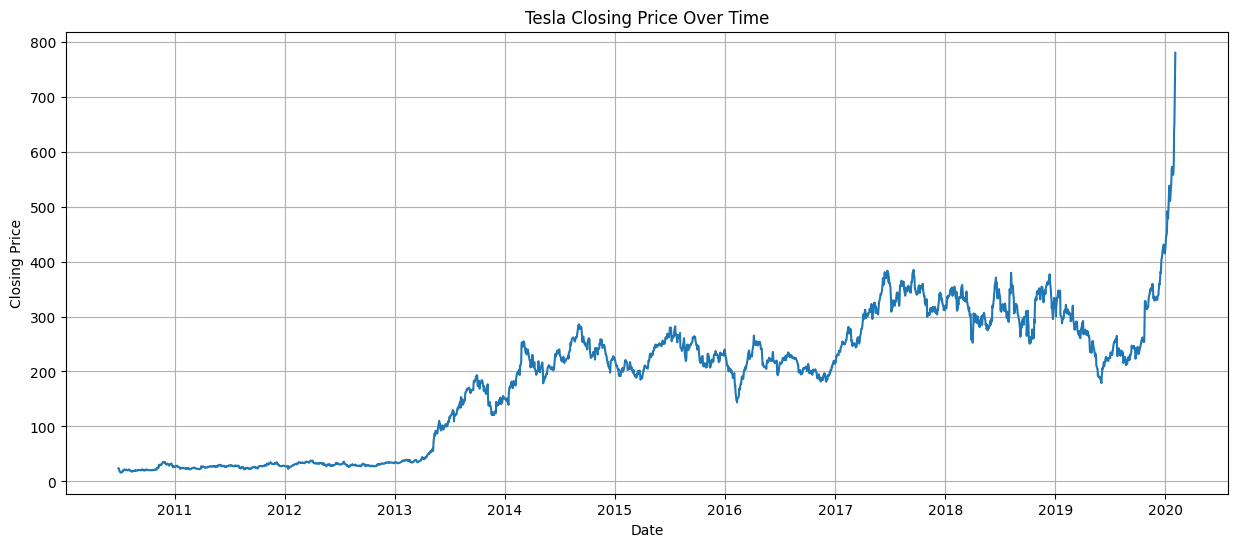

In [23]:
# Chart - 1 : Tesla Closing Price Trend

plt.figure(figsize=(15,6))

plt.plot(df_wrangle['Date'],
         df_wrangle['Close'])

plt.title('Tesla Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected because the dataset represents time-series data where stock prices are recorded over chronological dates. Line charts are the most effective visualization for identifying trends, patterns, fluctuations, and long-term movements in stock prices over time. Since the primary objective of the project is forecasting Tesla's closing price, visualizing the historical closing price trend provides a clear understanding of the behavior of the target variable.


##### 2. What is/are the insight(s) found from the chart?

The chart reveals that Tesla's stock price experienced significant fluctuations over time, indicating periods of growth, decline, and high volatility. An overall upward trend can be observed across the years, suggesting long-term growth in Tesla's market valuation. Several sharp increases and decreases are also visible, highlighting the influence of market conditions and investor sentiment on Tesla's stock performance.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights obtained from the chart can contribute to positive business impact. Understanding historical stock price trends helps investors, analysts, and financial institutions make informed investment decisions. The presence of identifiable trends and recurring patterns supports the use of deep learning models such as SimpleRNN and LSTM for forecasting future stock prices.

The chart also highlights periods of high volatility, which may indicate increased investment risk. While strong upward trends may encourage investment opportunities, sudden price fluctuations can lead to uncertainty and potential financial losses. Therefore, accurate forecasting models can help mitigate risks and improve decision-making in stock market trading and portfolio management.


#### Chart - 2

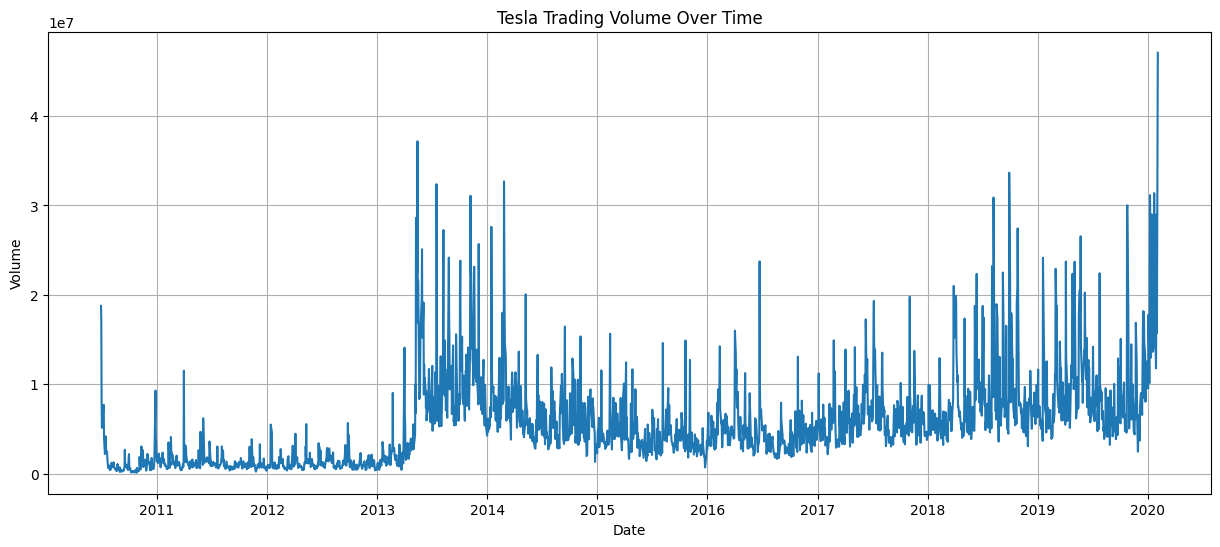

In [24]:
# Chart - 2 : Trading Volume Trend

plt.figure(figsize=(15,6))

plt.plot(df_wrangle['Date'],
         df_wrangle['Volume'])

plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen to visualize trading volume over time because volume is a time-dependent variable. Analyzing trading volume helps identify periods of high and low market activity, investor participation, and potential shifts in market sentiment. Since stock prices are often influenced by trading activity, understanding volume trends provides valuable context for forecasting stock price movements.


##### 2. What is/are the insight(s) found from the chart?

The chart shows fluctuations in Tesla's trading volume across different periods. Certain periods exhibit sharp spikes in volume, indicating increased investor interest and market activity. These spikes may correspond to major company announcements, earnings reports, product launches, or significant market events. The variation in trading volume suggests that investor sentiment and market participation have changed considerably over time.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from trading volume analysis can support positive business and investment decisions. High trading volume often indicates strong investor interest and improved market liquidity, making it easier for investors to enter or exit positions. Understanding volume trends can also help identify potential market opportunities and periods of increased volatility.

However, sudden spikes or extreme fluctuations in trading volume may indicate uncertainty or speculative trading behavior. Such periods can increase market risk and lead to unpredictable price movements. Therefore, combining volume analysis with stock price forecasting can improve risk management and investment decision-making.


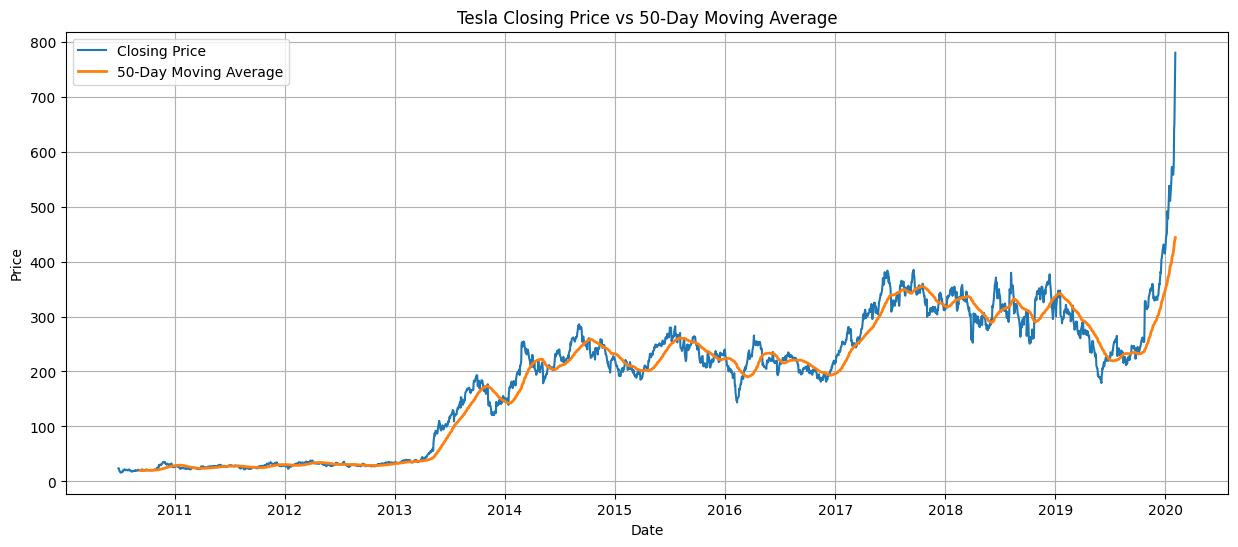

In [25]:
# Chart - 3 : Closing Price vs 50-Day Moving Average

df_wrangle['50_MA'] = df_wrangle['Close'].rolling(window=50).mean()

plt.figure(figsize=(15,6))

plt.plot(df_wrangle['Date'],
         df_wrangle['Close'],
         label='Closing Price')

plt.plot(df_wrangle['Date'],
         df_wrangle['50_MA'],
         label='50-Day Moving Average',
         linewidth=2)

plt.title('Tesla Closing Price vs 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

This chart was selected because moving averages are widely used in financial analysis to identify long-term trends and reduce short-term price fluctuations. Comparing Tesla's closing price with its 50-day moving average helps visualize the overall market direction and provides a clearer understanding of stock price behavior over time. Since the project focuses on forecasting future stock prices, understanding underlying trends is essential before developing predictive models.


##### 2. What is/are the insight(s) found from the chart?

The chart shows that the 50-day moving average smooths out daily price fluctuations and highlights the overall trend of Tesla's stock performance. The closing price frequently oscillates around the moving average, while the moving average itself follows a more stable trajectory. Periods where the closing price remains above the moving average generally indicate bullish market behavior, whereas periods below the moving average may indicate bearish trends or temporary market corrections.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this chart can support positive investment and financial decision-making. Moving averages help investors identify long-term market trends and reduce the impact of short-term volatility. Understanding these trends can assist in portfolio management, trading strategies, and risk assessment.

However, prolonged periods where the stock price remains below the moving average may indicate weakening market momentum or declining investor confidence. Such situations could potentially signal negative growth and increased investment risk. Therefore, monitoring moving average trends can help investors make more informed decisions and react proactively to changing market conditions.


#### Chart - 4

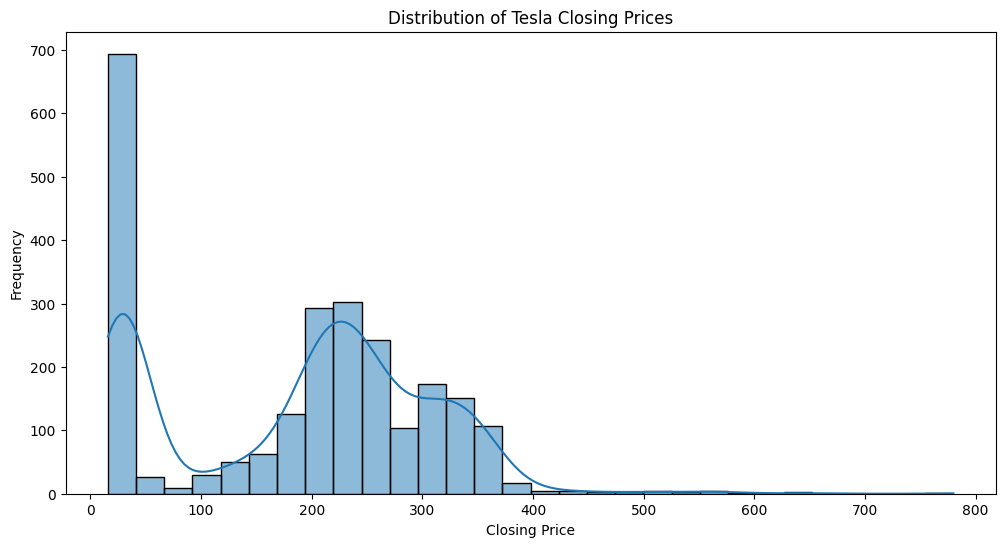

In [26]:
# Chart - 4 : Distribution of Tesla Closing Prices

plt.figure(figsize=(12,6))

sns.histplot(df_wrangle['Close'],
             bins=30,
             kde=True)

plt.title('Distribution of Tesla Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a density curve was selected to understand the distribution of Tesla's closing stock prices. This chart helps identify the concentration of stock prices, the spread of values, and the presence of extreme observations or outliers. Understanding the distribution of the target variable is important before developing forecasting models because it provides insight into price behavior and variability.


##### 2. What is/are the insight(s) found from the chart?

The chart shows how Tesla's closing prices are distributed across different price ranges. The distribution indicates that stock prices are not concentrated around a single value but vary significantly over time. The presence of higher-frequency ranges suggests periods where Tesla stock traded within specific price levels, while the tails of the distribution indicate occasional extreme price movements. This variability highlights the dynamic nature of Tesla's stock performance.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding the distribution of stock prices can support better investment and forecasting decisions. Identifying common trading ranges helps investors evaluate historical price behavior and assess potential future movements. The distribution also provides useful information for risk assessment and model development.

However, the presence of extreme price values or high variability may indicate periods of increased market volatility. Such fluctuations can increase investment risk and make stock price forecasting more challenging. Therefore, investors should consider both historical trends and volatility when making financial decisions.


#### Chart - 5

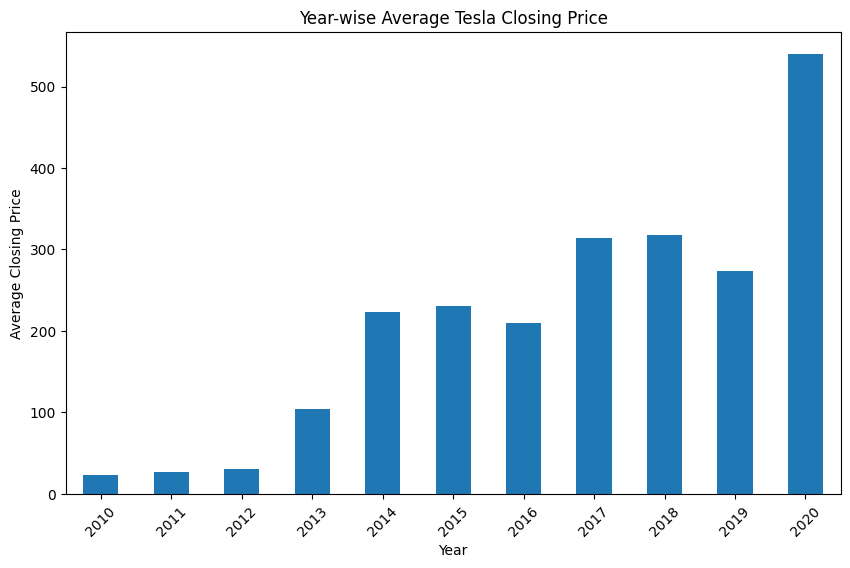

In [27]:
# Chart - 5 : Year-wise Average Closing Price

df_wrangle['Year'] = pd.to_datetime(df_wrangle['Date']).dt.year

yearly_avg = df_wrangle.groupby('Year')['Close'].mean()

plt.figure(figsize=(10,6))

yearly_avg.plot(kind='bar')

plt.title('Year-wise Average Tesla Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')

plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected to compare Tesla's average closing stock prices across different years. While daily stock prices provide detailed short-term information, yearly averages help reveal long-term growth trends and allow for easier comparison between different periods. This chart simplifies the analysis of Tesla's historical performance and highlights significant changes in stock valuation over time.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how Tesla's average closing price has evolved over the years. Certain years demonstrate substantial growth in average stock prices, reflecting increasing investor confidence and company expansion. Differences between years highlight periods of strong performance, market corrections, or slower growth. The chart provides a clear overview of Tesla's long-term stock market trajectory and demonstrates how the company's valuation has changed over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can support positive business and investment decisions by helping investors identify long-term growth patterns. Understanding yearly performance trends enables better evaluation of Tesla's market position and future investment potential. The chart also provides valuable context for forecasting future stock prices using deep learning models.

However, years showing lower average closing prices or declining trends may indicate market challenges, economic uncertainty, or reduced investor confidence. Such periods could negatively impact investment returns and signal increased risk. Therefore, analyzing yearly performance is important for long-term financial planning and risk management.

#### Chart - 6

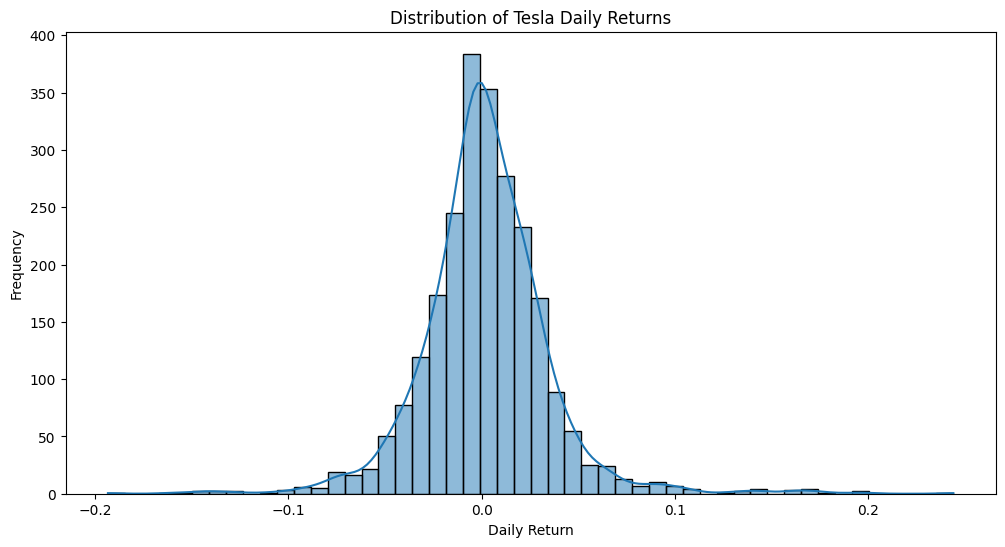

In [28]:
# Chart - 6 : Daily Returns Distribution

df_wrangle['Daily_Return'] = df_wrangle['Close'].pct_change()

plt.figure(figsize=(12,6))

sns.histplot(df_wrangle['Daily_Return'].dropna(),
             bins=50,
             kde=True)

plt.title('Distribution of Tesla Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A daily returns distribution chart was selected because it helps analyze stock volatility and price movement behavior. Instead of focusing on absolute stock prices, daily returns measure the percentage change between consecutive trading days. This provides a better understanding of risk, stability, and market fluctuations, which are important factors in stock price forecasting and financial analysis.


##### 2. What is/are the insight(s) found from the chart?

The chart illustrates how Tesla's daily returns are distributed over time. Most daily returns are concentrated around zero, indicating that large price changes occur less frequently than small price changes. However, the presence of extreme positive and negative returns demonstrates that Tesla stock experiences periods of significant volatility. These fluctuations highlight the dynamic nature of the stock market and the challenges associated with accurately predicting future prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from analyzing daily returns can support better investment and risk management decisions. Understanding the distribution of returns helps investors assess stock volatility, evaluate potential risks, and develop more informed trading strategies. Financial institutions can also use this information to improve portfolio allocation and risk mitigation practices.

However, the presence of extreme positive and negative returns indicates periods of high market volatility. Such volatility can increase uncertainty and investment risk, potentially leading to unexpected losses. Therefore, while Tesla stock may offer growth opportunities, investors should carefully consider the associated risks when making financial decisions.


#### Chart - 7

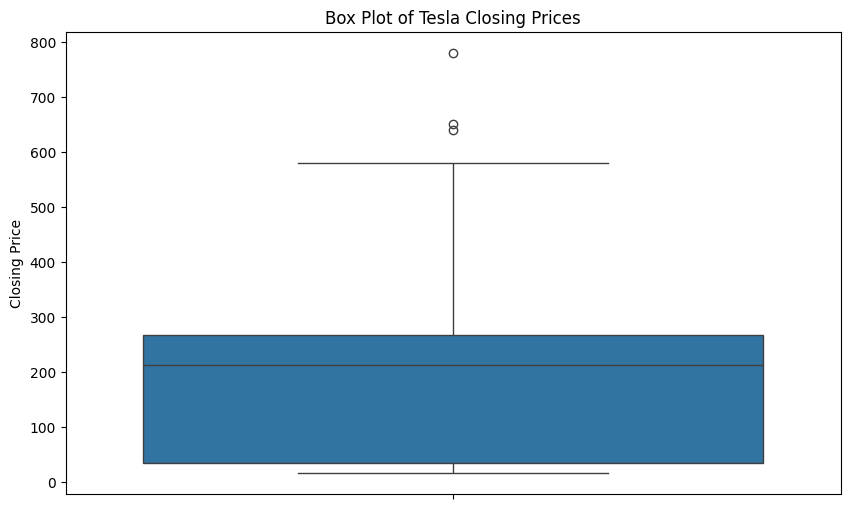

In [29]:
# Chart - 7 : Box Plot of Tesla Closing Prices

plt.figure(figsize=(10,6))

sns.boxplot(y=df_wrangle['Close'])

plt.title('Box Plot of Tesla Closing Prices')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected because it provides a concise summary of the distribution of Tesla's closing prices and helps identify outliers. Outliers are important in stock market analysis because extreme price movements can significantly influence model performance and forecasting accuracy. The box plot also visualizes the median, quartiles, and overall spread of the data.


##### 2. What is/are the insight(s) found from the chart?

The box plot reveals the distribution of Tesla's closing prices and highlights the presence of extreme values. The median price represents the central tendency of the stock, while the interquartile range shows the spread of the majority of observations. Any points lying outside the whiskers indicate potential outliers, which may correspond to periods of exceptional market activity, rapid growth, or significant market corrections. These observations reflect the volatile nature of Tesla's stock price movements.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights obtained from the box plot can support positive business and investment decisions by helping analysts understand stock price variability and detect unusual market behavior. Identifying outliers enables investors and data scientists to assess whether extreme price movements represent genuine market events or potential anomalies.

However, a large number of outliers may indicate high volatility and increased uncertainty in stock price behavior. Such volatility can increase investment risk and make forecasting more challenging. Therefore, understanding these extreme movements is essential for effective risk management and the development of reliable predictive models.


#### Chart - 8

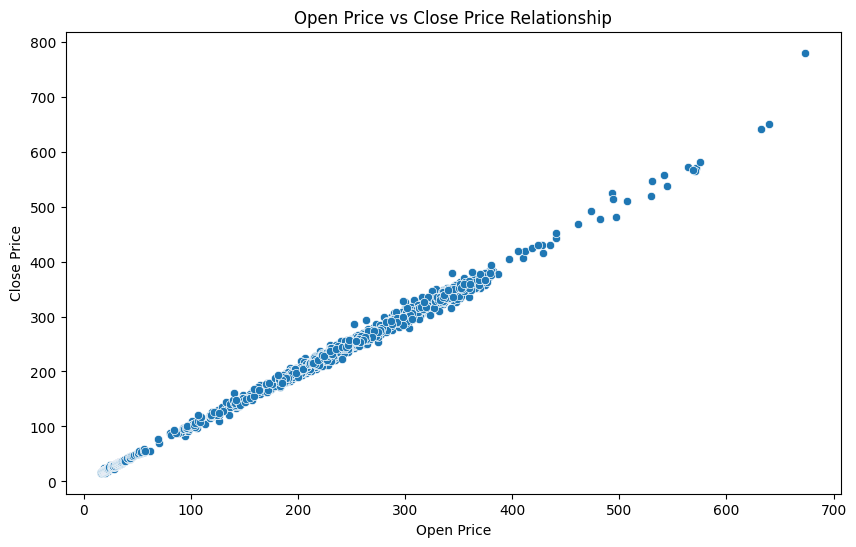

In [30]:
# Chart - 8 : Open Price vs Close Price Relationship

plt.figure(figsize=(10,6))

sns.scatterplot(x=df_wrangle['Open'], y=df_wrangle['Close'])

plt.title('Open Price vs Close Price Relationship')
plt.xlabel('Open Price')
plt.ylabel('Close Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected because it is highly effective for examining the relationship between two continuous variables. In this case, the chart helps visualize how Tesla's opening stock prices are related to its closing stock prices. Understanding this relationship is important because it provides insights into daily price movements and market behavior. Additionally, scatter plots help identify trends, correlations, and unusual observations within the dataset.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot demonstrates a strong positive relationship between Tesla's opening and closing prices. Most data points are concentrated along an upward-sloping pattern, indicating that higher opening prices are generally associated with higher closing prices. This suggests consistency in daily stock price behavior. The chart may also reveal a few scattered observations that represent days with significant price fluctuations, which could be associated with major market events, company announcements, or changes in investor sentiment.The scatter plot demonstrates a strong positive relationship between Tesla's opening and closing prices. Most data points are concentrated along an upward-sloping pattern, indicating that higher opening prices are generally associated with higher closing prices. This suggests consistency in daily stock price behavior. The chart may also reveal a few scattered observations that represent days with significant price fluctuations, which could be associated with major market events, company announcements, or changes in investor sentiment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights obtained from this chart can contribute to positive business and investment decisions. The strong correlation between opening and closing prices indicates predictable market behavior, which can support forecasting models and trading strategies. Investors can use this information to better understand stock movement patterns and make more informed decisions.

However, the presence of observations that deviate from the general trend may indicate periods of increased volatility. Such fluctuations can introduce uncertainty and risk into investment decisions. If these deviations become more frequent, they may reduce the reliability of predictions and increase exposure to market instability. Therefore, monitoring these variations is important for effective risk management and financial planning.

#### Chart - 9

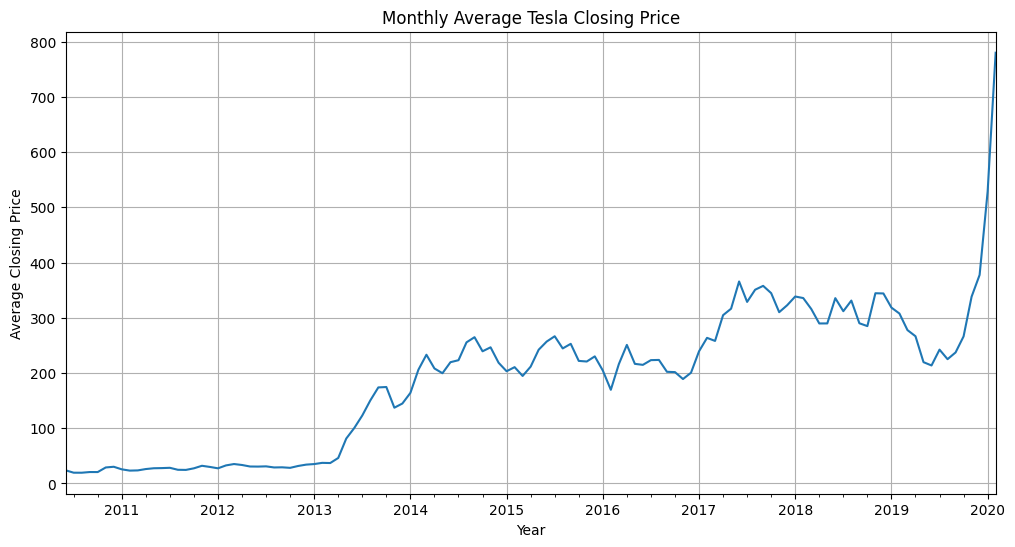

In [31]:
# Chart - 9 : Monthly Average Closing Price Trend

monthly_close = df_wrangle.resample('M', on='Date')['Close'].mean()

plt.figure(figsize=(12,6))
monthly_close.plot()

plt.title('Monthly Average Tesla Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart of monthly average closing prices was selected to analyze Tesla's long-term stock price trend while reducing short-term market noise. Daily stock prices can fluctuate significantly due to temporary market events, making it difficult to identify overall patterns. Aggregating prices on a monthly basis provides a clearer view of the stock's growth trajectory and long-term performance.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the overall trend in Tesla's stock performance over time. It shows periods of sustained growth, stability, and occasional declines. By observing monthly averages rather than daily values, broader market patterns become more visible. Significant upward movements may indicate periods of strong investor confidence and business expansion, while downward trends may correspond to market corrections or economic uncertainty. The chart also demonstrates that Tesla's stock price has experienced notable fluctuations while maintaining long-term growth characteristics.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this chart can support positive business and investment decisions by helping stakeholders understand Tesla's long-term market performance. Investors can use these trends to evaluate growth potential, identify favorable investment periods, and support strategic decision-making. The chart also provides valuable information for forecasting models by revealing long-term patterns in stock behavior.

However, periods of declining monthly average prices may indicate reduced investor confidence, unfavorable market conditions, or company-specific challenges. Prolonged downward trends could negatively impact investment returns and increase uncertainty in forecasting future stock performance. Therefore, monitoring long-term trends is essential for risk assessment and portfolio management.

#### Chart - 10

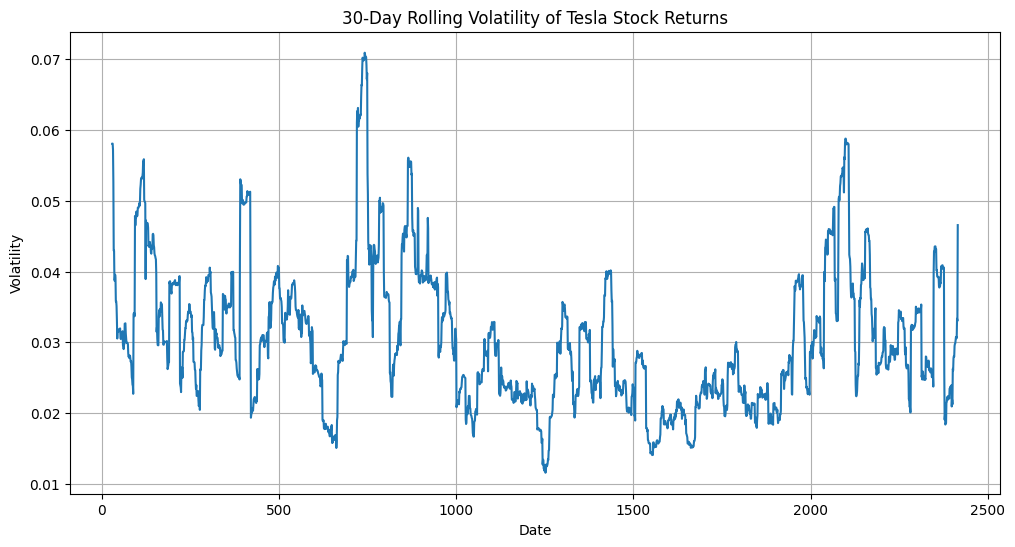

In [32]:
# Chart - 10 : Rolling Volatility of Tesla Stock Returns

df_wrangle['Daily_Return'] = df_wrangle['Close'].pct_change()

rolling_volatility = df_wrangle['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(rolling_volatility)

plt.title('30-Day Rolling Volatility of Tesla Stock Returns')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A rolling volatility chart was selected because volatility is one of the most important indicators in stock market analysis. While stock prices show the direction of movement, volatility measures the degree of uncertainty and risk associated with those movements. The 30-day rolling volatility helps identify periods when Tesla's stock experienced stable behavior and periods when it underwent significant fluctuations. This information is valuable for both investors and predictive modeling.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights changes in Tesla's stock price volatility over time. Periods with higher volatility indicate larger fluctuations in daily returns and greater market uncertainty. Conversely, periods with lower volatility suggest more stable stock behavior. Peaks in the volatility curve may correspond to major company announcements, market events, economic changes, or shifts in investor sentiment. The chart demonstrates that Tesla's stock has experienced varying levels of risk throughout its trading history.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights gained from this chart can support positive business and investment decisions. Understanding volatility helps investors evaluate risk levels, optimize portfolio strategies, and make informed trading decisions. For machine learning and deep learning models, volatility analysis provides additional context about market behavior and can improve forecasting reliability.

However, sustained periods of high volatility may indicate increased uncertainty and investment risk. Large fluctuations in stock prices can discourage risk-averse investors and make future price movements more difficult to predict accurately. If volatility remains consistently high, it may negatively affect investor confidence and increase exposure to financial losses.

#### Chart - 11

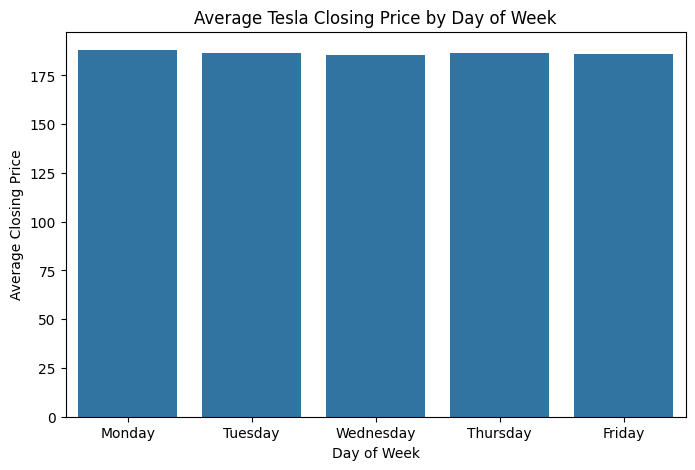

In [33]:
# Chart 11: Average Closing Price by Day of Week

df['Day_of_Week'] = pd.to_datetime(df['Date']).dt.day_name()

daywise_close = df.groupby('Day_of_Week')['Close'].mean()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daywise_close = daywise_close.reindex(day_order)

plt.figure(figsize=(8,5))
sns.barplot(x=daywise_close.index, y=daywise_close.values)

plt.title('Average Tesla Closing Price by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?



This chart was selected to examine whether Tesla's average closing prices vary across different trading days of the week. Identifying weekday-based patterns can help understand short-term market behavior and potential trading opportunities.

##### 2. What is/are the insight(s) found from the chart?

1. The average closing price differs slightly across weekdays.
2.  Some trading days may exhibit higher average closing prices compared to others.
3. The chart helps identify recurring weekly patterns in Tesla's stock performance.
4. Investors can observe whether certain days historically show stronger market performance.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can contribute to positive business impact. Understanding day-of-week behavior helps investors and traders plan entry and exit strategies more effectively. If a particular weekday consistently demonstrates stronger performance, it may support short-term trading decisions.

However, relying solely on weekday patterns may lead to inaccurate decisions because stock prices are influenced by broader market conditions, company news, economic indicators, and investor sentiment. Therefore, weekday analysis should be used alongside other financial indicators for better decision-making.

#### Chart - 12

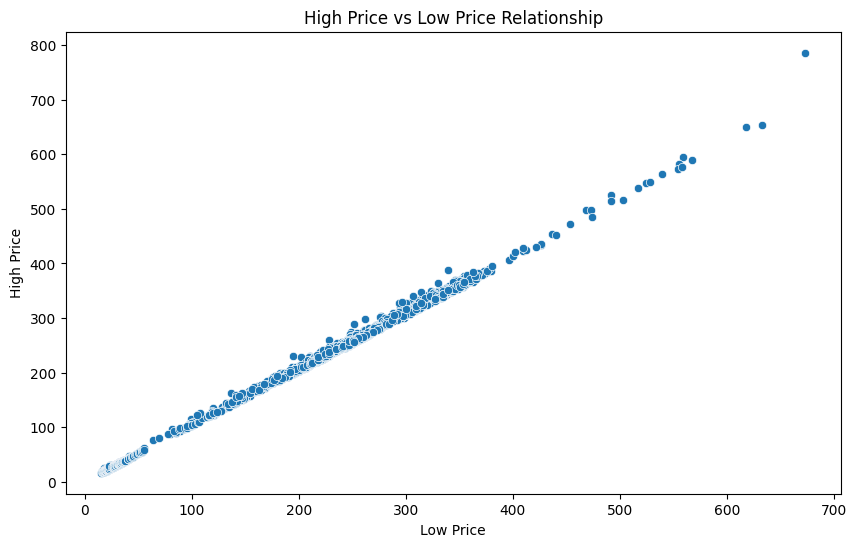

In [34]:
# Chart - 12 : High Price vs Low Price Relationship

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df_wrangle['Low'],
    y=df_wrangle['High']
)

plt.title('High Price vs Low Price Relationship')
plt.xlabel('Low Price')
plt.ylabel('High Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between Tesla's daily low prices and high prices. Since both variables represent the price range within a trading day, understanding their relationship helps evaluate stock volatility and trading behavior. This chart also helps identify whether daily price movements follow a consistent pattern and whether any unusual trading days exist in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive relationship between daily low prices and high prices. As the low price increases, the high price generally increases as well, indicating consistent price movement throughout trading sessions. Most observations are concentrated along a linear pattern, suggesting stable relationships between daily trading ranges. A few scattered points may represent days with unusually large price swings, reflecting heightened market activity or significant company-related events.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this chart can support positive business and investment decisions by providing a better understanding of Tesla's daily trading range and price behavior. Investors and analysts can use this information to assess market stability, evaluate trading opportunities, and improve forecasting models.

However, observations that deviate significantly from the overall trend may indicate periods of increased volatility. Large gaps between daily high and low prices can signal market uncertainty and elevated investment risk. If such fluctuations occur frequently, they may reduce investor confidence and make stock price prediction more challenging. Therefore, monitoring daily trading ranges is important for effective risk management and strategic decision-making.

#### Chart - 13

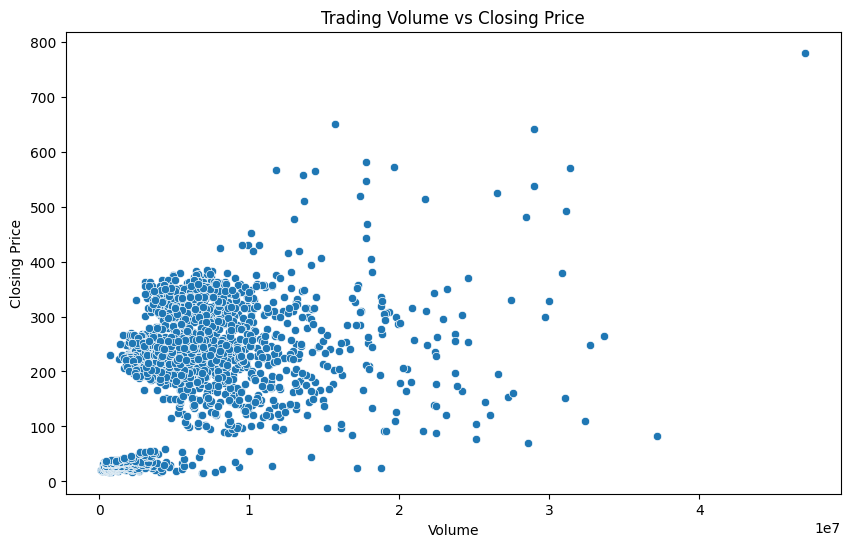

In [35]:
# Chart - 13 : Trading Volume vs Closing Price

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df_wrangle['Volume'],
    y=df_wrangle['Close']
)

plt.title('Trading Volume vs Closing Price')
plt.xlabel('Volume')
plt.ylabel('Closing Price')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected because it effectively visualizes the relationship between trading volume and Tesla's closing stock price. Trading volume is an important market indicator that reflects investor participation and market activity. By examining volume alongside closing prices, we can better understand whether changes in stock price are associated with increased or decreased trading activity.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how Tesla's closing prices vary across different trading volumes. Periods of high trading volume often coincide with significant price movements, indicating strong investor interest and market participation. The scatter pattern may reveal clusters where normal trading activity occurs and a few extreme observations representing unusual market events. The relationship suggests that volume plays an important role in influencing stock price behavior and market momentum.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights from this chart can support positive business and investment decisions. Understanding the relationship between trading volume and stock prices helps investors identify periods of strong market interest and potential investment opportunities. High trading volume combined with rising prices often indicates positive market sentiment and increased investor confidence.

However, unusually high trading volumes accompanied by sharp price declines may indicate panic selling, negative market sentiment, or adverse company-specific events. Such situations can increase market volatility and investment risk. If these patterns occur frequently, they may negatively impact investor confidence and make stock price forecasting more challenging. Therefore, monitoring trading volume alongside stock prices is essential for risk assessment and informed decision-making.

#### Chart - 14 - Correlation Heatmap

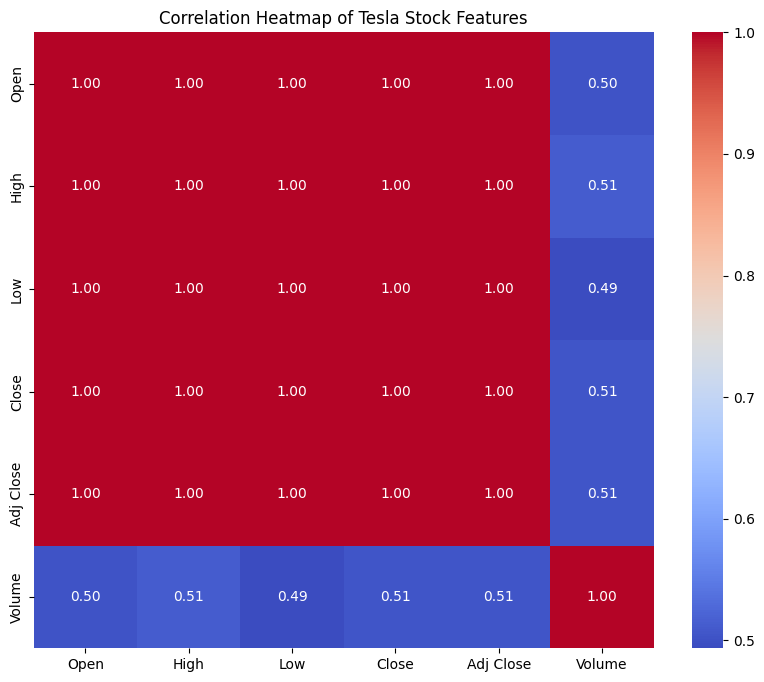

In [36]:
# Chart - 14 : Correlation Heatmap

plt.figure(figsize=(10,8))

correlation_matrix = df_wrangle[['Open',
                                 'High',
                                 'Low',
                                 'Close',
                                 'Adj Close',
                                 'Volume']].corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap of Tesla Stock Features')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was selected because it provides a clear and efficient way to visualize the relationships between multiple numerical variables in the Tesla stock dataset. It helps identify the strength and direction of correlations among features such as Open, High, Low, Close, Adjusted Close, and Volume. Understanding these relationships is essential for feature selection, reducing redundancy, and improving the performance of deep learning models used for stock price prediction.

##### 2. What is/are the insight(s) found from the chart?

The correlation heatmap reveals that Tesla's price-related variables, including Open, High, Low, Close, and Adjusted Close, exhibit very strong positive correlations with one another. This indicates that these features move together and contain highly related information about stock price behavior. The Close Price, which serves as the target variable for prediction, shows a particularly strong relationship with the other price-based features, suggesting that historical price information is highly valuable for forecasting future stock prices.

The Volume feature generally demonstrates a weaker correlation with the price-related variables. This suggests that trading activity does not always move in direct proportion to stock prices. The heatmap also highlights potential feature redundancy due to strong correlations among several variables, confirming that Tesla's stock data contains meaningful patterns that can be leveraged by deep learning models such as SimpleRNN and LSTM for accurate time-series forecasting.

#### Chart - 15 - Pair Plot

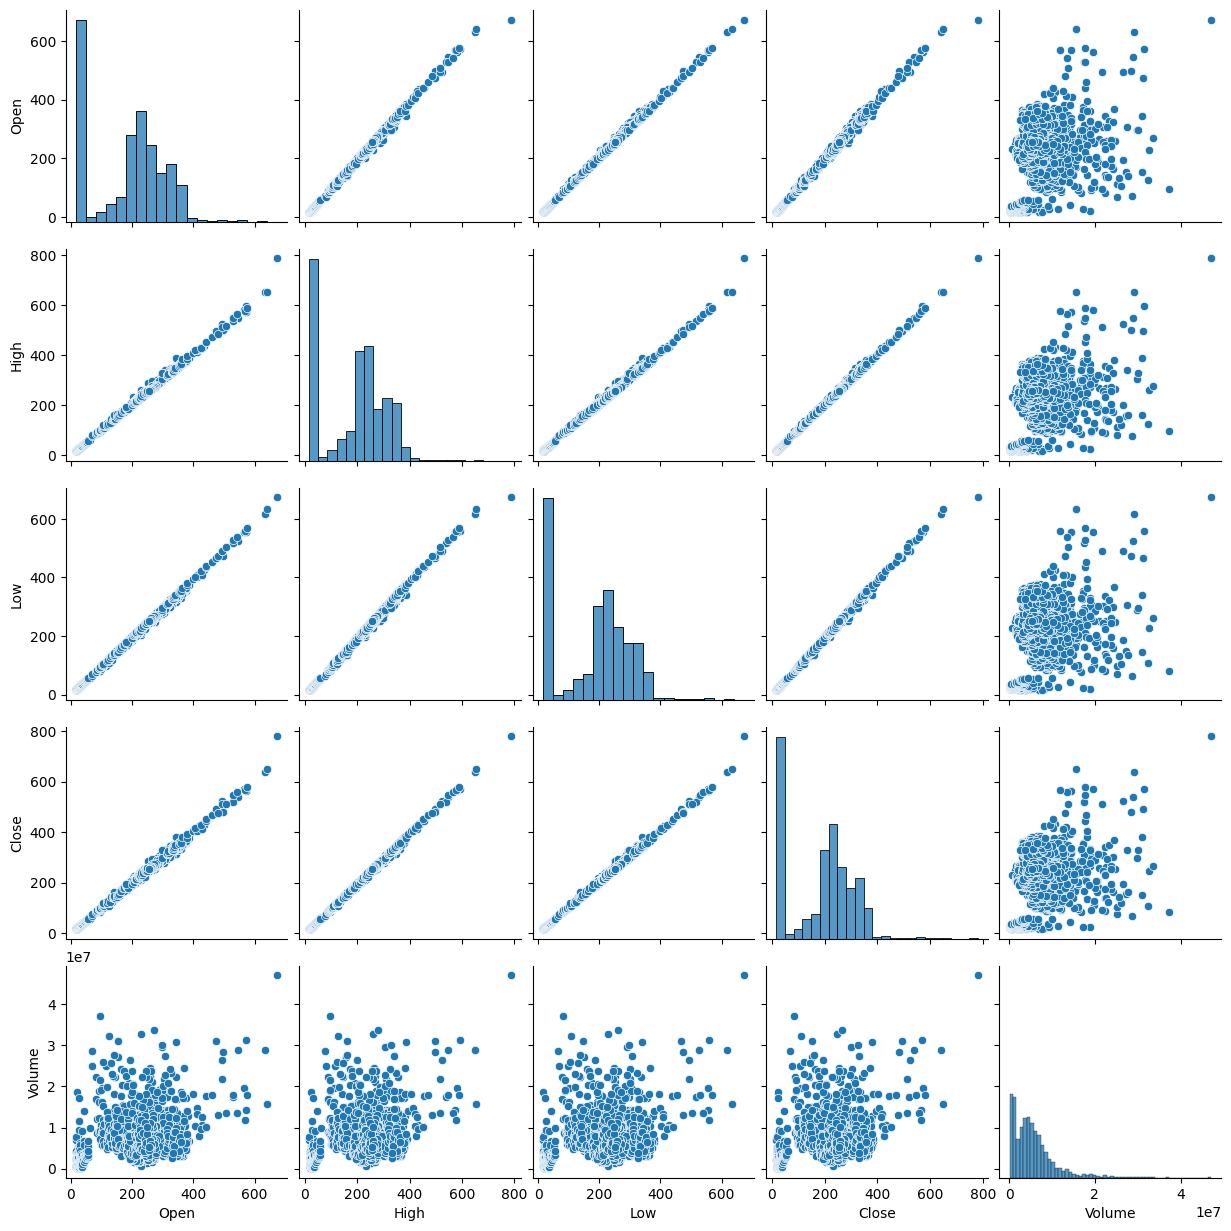

In [37]:
# Chart - 15 : Pair Plot

selected_features = ['Open', 'High', 'Low', 'Close', 'Volume']

sns.pairplot(df_wrangle[selected_features])

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it provides a comprehensive visualization of the relationships among multiple numerical variables simultaneously. Unlike individual scatter plots that examine only two variables at a time, a pair plot displays pairwise relationships, distributions, and potential correlations across all selected features in a single visualization. This makes it particularly useful for exploratory data analysis, helping identify patterns, trends, clusters, and potential dependencies within Tesla's stock market data.

##### 2. What is/are the insight(s) found from the chart?

The pair plot reveals strong positive relationships among Tesla's price-related variables, including Open, High, Low, and Close prices. The scatter plots generally show linear upward patterns, indicating that these variables move closely together. The diagonal plots display the distribution of each feature, providing insight into their spread and variability.

The chart also highlights that Volume behaves differently from price-related variables and exhibits weaker relationships with them. This suggests that trading activity does not always directly correspond to stock price changes. Overall, the pair plot confirms the presence of strong interdependencies among stock price features and provides valuable insights into the structure of the dataset before model development.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on chart experiments, the following hypothetical statements were formulated:
1. There is a significant difference between Tesla's opening and closing stock prices.
2. Tesla's daily returns have a mean significantly different from zero.
3. Trading volume has a significant relationship with Tesla's closing stock price.

### Hypothetical Statement - 1

There is a significant difference between Tesla's Opening Price and Closing Price.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant difference between Tesla's average Opening Price and average Closing Price.

H0:μ Open =μ Close
	​
Alternate Hypothesis (H₁):

There is a significant difference between Tesla's average Opening Price and average Closing Price.

H1 :μ Open != μ Close
	​



#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value

In [39]:
from scipy.stats import ttest_rel

# Paired T-Test
t_stat, p_value = ttest_rel(df_wrangle['Open'],
                            df_wrangle['Close'])

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

T-Statistic: -1.1572178332385585
P-Value: 0.2472978181045662
Fail to Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

A Paired Sample T-Test was performed to obtain the P-value.

P-Value: 0.2472978181045662

##### Why did you choose the specific statistical test?

The Paired Sample T-Test was selected because the Opening Price and Closing Price are measured on the same trading day and therefore represent paired observations. This test is designed to determine whether the mean difference between two related samples is statistically significant. Since the objective is to compare Tesla's opening and closing prices across the same dates, the paired t-test is the most appropriate statistical method.

Conclusion
Since the P-value (0.2473) is greater than 0.05, we fail to reject the null hypothesis. Therefore, there is no statistically significant difference between Tesla's average Opening Price and Closing Price at the 5% significance level.

### Hypothetical Statement - 2

There is a significant relationship between EDA on Daily Returns

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

The mean daily return of Tesla stock is equal to zero.

H0:μ=0

Alternate Hypothesis (H₁):

The mean daily return of Tesla stock is not equal to zero.

H1:μ!=0

This tests whether Tesla generates a statistically significant average daily return.

#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value

In [41]:
from scipy.stats import ttest_1samp

# Remove missing values
daily_returns = df_wrangle['Daily_Return'].dropna()

# One Sample T-Test
t_stat, p_value = ttest_1samp(daily_returns, 0)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

T-Statistic: 2.9632037455347744
P-Value: 0.0030743140639453276
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

A One-Sample T-Test was performed to obtain the P-value.

P-Value: 0.0030743140639453276


##### Why did you choose the specific statistical test?

The One-Sample T-Test was selected because it is used to determine whether the mean of a sample differs significantly from a known or hypothesized value. In this case, the test evaluates whether Tesla's average daily return is significantly different from zero. Since daily returns are numerical observations and the objective is to compare their mean against a fixed benchmark value (0), the One-Sample T-Test is the most appropriate statistical method.

Since the P-value (0.0031) is less than 0.05, the null hypothesis is rejected. Therefore, Tesla's average daily return is significantly different from zero. This suggests that the stock demonstrates meaningful return behavior that may be useful for forecasting future price movements and supporting investment decisions.

### Hypothetical Statement - 3

There is a significant relationship between Tesla's Trading Volume and Closing Price.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant correlation between Tesla's Trading Volume and Closing Price.

H0 :ρ=0

Alternate Hypothesis (H₁):

There is a significant correlation between Tesla's Trading Volume and Closing Price.

H1:ρ !=0

#### 2. Perform an appropriate statistical test.

In [42]:
# Perform Statistical Test to obtain P-Value

In [43]:
from scipy.stats import pearsonr

# Pearson Correlation Test
corr_coef, p_value = pearsonr(
    df_wrangle['Volume'],
    df_wrangle['Close']
)

print("Correlation Coefficient:", corr_coef)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Correlation Coefficient: 0.5051687710379746
P-Value: 1.1524503805826938e-156
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

A Pearson Correlation Test was performed to determine whether a statistically significant relationship exists between Tesla's Trading Volume and Closing Price.

P-Value: 1.1524503805826938e-156

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was selected because it measures the strength and direction of the linear relationship between two continuous numerical variables. In this analysis, Trading Volume and Closing Price are numerical variables, and the objective is to evaluate whether changes in trading activity are significantly associated with changes in Tesla's stock price. The test provides both a correlation coefficient and a P-value, making it suitable for assessing the significance of the relationship.

Since the P-value (1.152 × 10⁻¹⁵⁶) is significantly smaller than the significance level of 0.05, the null hypothesis is rejected. Therefore, there is strong statistical evidence to conclude that a significant relationship exists between Tesla's Trading Volume and Closing Price. This suggests that trading activity plays an important role in stock price behavior and may provide valuable information for forecasting future price movements. Understanding this relationship can help investors, analysts, and predictive models make more informed financial decisions.

### Hypothetical Statement - 4

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):

There is no significant correlation between Tesla's Trading Volume and Daily Returns.

H₀: ρ = 0

Alternate Hypothesis (H₁):

There is a significant correlation between Tesla's Trading Volume and Daily Returns.

H₁: ρ ≠ 0

#### 2. Perform an appropriate statistical test.

In [44]:
from scipy.stats import pearsonr

# Remove missing values for Daily_Return
daily_returns_cleaned = df_wrangle['Daily_Return'].dropna()
volume_aligned = df_wrangle.loc[daily_returns_cleaned.index, 'Volume']

# Pearson Correlation Test
corr_coef, p_value = pearsonr(
    volume_aligned,
    daily_returns_cleaned
)

print("Correlation Coefficient:", corr_coef)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Correlation Coefficient: 0.07481075333073396
P-Value: 0.00023355215865009842
Reject Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

A Pearson Correlation Test was performed to determine if a statistically significant linear relationship exists between Tesla's Trading Volume and Daily Returns.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both 'Trading Volume' and 'Daily Returns' are continuous numerical variables, and we want to assess the strength and direction of their linear relationship. This test provides both a correlation coefficient (ρ) and a p-value, which allows us to statistically determine if the observed correlation is significant or due to random chance.

##### Conclusion

Based on the p-value obtained from the Pearson Correlation Test, we can conclude whether to reject or fail to reject the null hypothesis. If the p-value is less than the significance level (e.g., 0.05), we reject the null hypothesis, indicating a significant correlation. Otherwise, we fail to reject the null hypothesis, suggesting no significant linear correlation.

### Data Preparation for SimpleRNN and LSTM Models

To prepare the Tesla stock dataset for Deep Learning models (SimpleRNN and LSTM), the following steps were performed:

#### 1. Feature Engineering and Handling Missing Values

New features were created from the original dataset to capture additional stock market behavior and improve exploratory analysis. These include Price_Range (High - Low), Daily_Return ((Close - Open) / Open), and Moving Averages such as MA_7 (7-day moving average) and MA_30 (30-day moving average) of the closing price. Any missing values generated due to rolling window calculations were removed to maintain data consistency and ensure clean input for model development.

#### 2. Feature Selection

The Date column was converted into datetime format and used to preserve the chronological order of the stock market data. Since the objective of this project is to predict Tesla's stock price behavior, the Close Price was selected as the target variable. Historical closing prices were utilized to create sequential observations for time-series forecasting.

#### 3. Data Scaling

MinMaxScaler was applied to normalize the stock prices between 0 and 1. Scaling is an essential preprocessing step for Deep Learning models such as SimpleRNN and LSTM because it improves training stability, accelerates convergence, and prevents features with larger numerical values from dominating the learning process.

#### 4. Time-Series Sequence Creation

The stock price data was transformed into sequential input-output pairs using a sliding window approach. A sequence of previous trading days was used as input to predict the next day's closing price. This process enables the models to learn temporal dependencies and historical stock price patterns effectively.

#### 5. Data Splitting

The processed dataset was split chronologically into training and testing sets using an 80:20 ratio. Random shuffling was avoided to preserve the time-series nature of the data and prevent data leakage. The training set was used to learn historical stock price patterns, while the testing set was reserved for evaluating the predictive performance of the SimpleRNN and LSTM models on unseen data.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [45]:
# Handling Missing Values & Missing Value Imputation

In [46]:
df = df.dropna()

In [47]:
df.dropna()

,Date,Open,High,Low,Close,Adj Close,Volume,Day_of_Week
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300,Tuesday
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,Wednesday
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,Thursday
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,Friday
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,Tuesday
...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,Tuesday
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,Wednesday
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,Thursday
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,Friday


#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset was first examined for missing values using functions such as isnull() and sum(). The analysis revealed that the dataset contained very few missing values. Since stock market data is sequential and time-dependent, rows containing missing values were removed using the dropna() method to maintain data integrity and avoid introducing artificial values into the time series.

Additionally, missing values generated during feature engineering, such as the calculation of daily returns (pct_change()) and moving averages (rolling()), were also removed. These missing values occurred naturally because the first observation does not have a previous value for comparison, and moving averages require a sufficient number of previous observations.

The dropna() technique was chosen because:

The number of missing values was very small compared to the overall dataset size.
Removing a few observations had a negligible impact on the dataset.
It preserved the accuracy and reliability of the stock price data.
It prevented potential bias that could arise from filling missing values with estimated values such as mean or median.

As a result, the dataset became clean, consistent, and suitable for Exploratory Data Analysis (EDA), hypothesis testing, feature engineering, and deep learning model development using SimpleRNN and LSTM models for stock price forecasting.

### 2. Handling Outliers

In [48]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

No explicit outlier treatment was performed. Stock market data naturally contains extreme price movements that represent genuine market behavior. Removing these observations could eliminate important information required for forecasting. Therefore, outliers were retained to preserve the authenticity of Tesla's stock price patterns.

### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding techniques were required because the dataset contains only numerical variables. Encoding methods such as Label Encoding and One-Hot Encoding are used for categorical data, which was not present in this dataset.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

No textual preprocessing required

The Tesla stock dataset contains only numerical and date features.

No textual columns are available for NLP preprocessing.

Textual preprocessing was not performed because the Tesla stock dataset contains only numerical and date-based features. NLP preprocessing techniques such as tokenization, stopword removal, stemming, lemmatization, POS tagging, and vectorization are not applicable.

#### 1. Expand Contraction

 Not Applicable

#### 2. Lower Casing

 Not Applicable

#### 3. Removing Punctuations

Not Applicable

#### 4. Removing URLs & Removing words and digits contain digits.

Not Applicable

#### 5. Removing Stopwords & Removing White spaces

Not Applicable

#### 6. Rephrase Text

Not Applicable

#### 7. Tokenization

Not Applicable

#### 8. Text Normalization

Not Applicable

##### Which text normalization technique have you used and why?

Text normalization was not required because the dataset does not contain textual features. The dataset consists of numerical stock market variables and date information.

#### 9. Part of speech tagging

Not Applicable

#### 10. Text Vectorization

Not Applicable

##### Which text vectorization technique have you used and why?

Text vectorization techniques were not applied because there is no text data available in the dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [49]:
# Manipulate Features to minimize feature correlation and create new features

In [51]:
df_processed = df_wrangle.copy()
df_processed['Price_Range'] = df_processed['High'] - df_processed['Low']
df_processed['Daily_Return'] = (df_processed['Close'] - df_processed['Open']) / df_processed['Open']

df_processed['MA_7'] = df_processed['Close'].rolling(window=7).mean()
df_processed['MA_30'] = df_processed['Close'].rolling(window=30).mean()

df_processed.dropna(inplace=True)

Feature selection was performed by analyzing correlations among stock market variables. Highly relevant features such as Open, High, Low, Volume, Daily_Return, Price_Range, and Moving Averages were retained because they provide useful information for forecasting Tesla's closing price.

#### 2. Feature Selection

In [52]:
# Select your features wisely to avoid overfitting

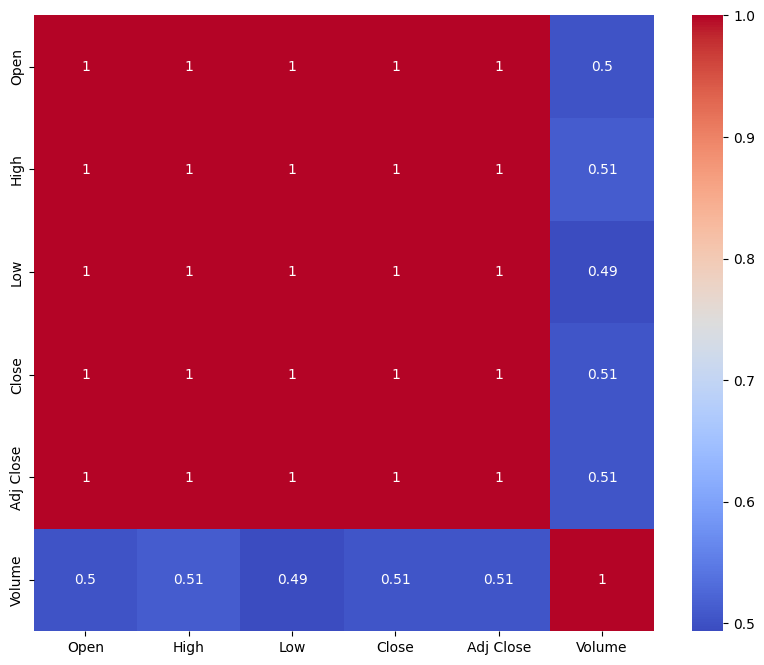

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

##### What all feature selection methods have you used  and why?

Correlation analysis was used to identify relationships between features and the target variable. Features with strong predictive power and financial relevance were selected while avoiding redundant features that could lead to overfitting.

##### Which all features you found important and why?

Open, High, Low, Volume, Daily Return, Price Range, and Moving Average features were found important because they directly influence stock price movements and provide information about market trends and trading activity.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

MinMaxScaler was applied to normalize the stock price values between 0 and 1. Normalization is particularly important for SimpleRNN and LSTM models because it improves training efficiency and helps the models learn temporal patterns more effectively.

In [54]:
# Transform Your data

In [55]:
# Date column is already datetime in df_processed (from df_wrangle conversion)
# No change needed here, as df_processed['Date'] is already datetime.

In [56]:
# Drop Date column from the processed DataFrame for model training
df_model_features = df_processed.drop('Date', axis=1)

### 6. Data Scaling

In [57]:
# Scaling your data

In [58]:
from sklearn.preprocessing import StandardScaler

X = df_model_features.drop('Close', axis=1)
y = df_model_features['Close']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?

MinMaxScaler was selected because neural network-based models such as SimpleRNN and LSTM are sensitive to feature scale. Scaling ensures faster convergence and better predictive performance.

In [59]:
data = df_processed[['Close']]

Time Series Sequence Creation

In [60]:
scaled_data = MinMaxScaler().fit_transform(data)

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [62]:
# Create Sequences

look_back = 60

X = []
y = []

for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2307, 60)
(2307,)


Reshape Data for RNN/LSTM

In [63]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(2307, 60, 1)


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality Reduction was not performed. The dataset contains a limited number of meaningful financial features, and retaining all relevant variables helps preserve important information for stock price prediction.

In [64]:
# DImensionality Reduction (If needed)

In [65]:
# Dimensionality Reduction not required

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Dimensionality reduction was not applied because the dataset contains a manageable number of informative features and model performance can be achieved without reducing feature dimensions.

### 8. Data Splitting

In [66]:
# Split your data to train and test. Choose Splitting ratio wisely.

In [67]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

##### What data splitting ratio have you used and why?

The dataset was split chronologically into training and testing datasets using an 80:20 ratio. Random shuffling was avoided to preserve the sequential nature of stock market data and prevent data leakage.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. This project is a regression problem where the target variable is a continuous stock price. Class imbalance is generally associated with classification problems and therefore is not applicable in this case.

In [68]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was required because the task involves predicting continuous stock prices rather than class labels.

## ***7. ML Model Implementation***

### ML Model - 1 : SimpleRNN

In [69]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

In [70]:
# ML Model - 1 : SimpleRNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Model

model_rnn = Sequential()

model_rnn.add(
    SimpleRNN(
        units=50,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

# Compile Model

model_rnn.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Prediction

rnn_pred = model_rnn.predict(X_test)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0126 - val_loss: 0.0050
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0019 - val_loss: 0.0040
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.9120e-04 - val_loss: 0.0026
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.2405e-04 - val_loss: 0.0021
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4940e-04 - val_loss: 0.0015
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.0486e-04 - val_loss: 0.0018
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.4346e-04 - val_loss: 0.0013
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.0627e-04 - val_loss: 0.0011
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2510e-04 - val_loss: 0.0018
Epoch 12/20
58/58 ━━━━━━━━━━━━━━━━━

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

SimpleRNN was selected because stock prices are sequential time-series data where previous observations influence future values. The model learns temporal dependencies from historical Tesla stock prices and captures short-term patterns in the closing price movements.

The evaluation metrics MAE, MSE, and RMSE were used to assess prediction performance. Lower values indicate better predictive accuracy. The chart provides a visual representation of the model's forecasting error and helps evaluate how effectively the SimpleRNN model predicts Tesla's stock prices.

In [71]:
# Visualizing evaluation Metric Score chart

In [72]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Evaluation Metrics

rnn_mae = mean_absolute_error(y_test, rnn_pred)

rnn_mse = mean_squared_error(y_test, rnn_pred)

rnn_rmse = np.sqrt(rnn_mse)

# Create Score Table

rnn_scores = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE'],
    'Score':[rnn_mae,rnn_mse,rnn_rmse]
})

rnn_scores

,Metric,Score
0,MAE,0.015351
1,MSE,0.000528
2,RMSE,0.022989


### Evaluation Metric Score Chart

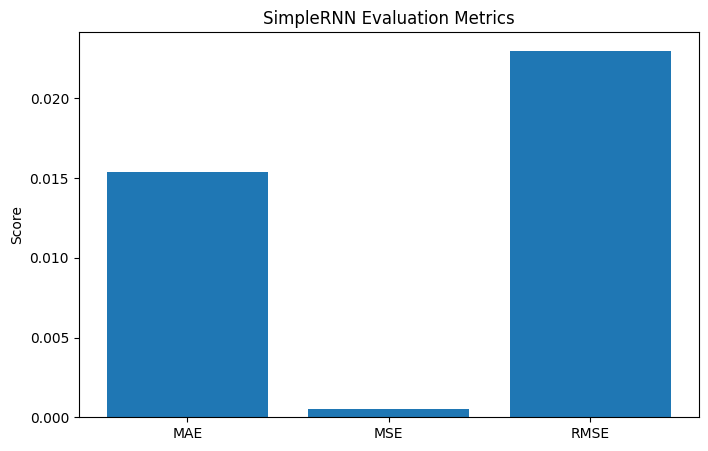

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    rnn_scores['Metric'],
    rnn_scores['Score']
)

plt.title('SimpleRNN Evaluation Metrics')
plt.ylabel('Score')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [74]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

### Using Keras Tuner instead

In [75]:
!pip install keras-tuner -q

### Hyper Parameter Tuning Code

In [76]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def build_rnn(hp):

    model = Sequential()

    model.add(
        SimpleRNN(
            units=hp.Int(
                'units',
                min_value=32,
                max_value=128,
                step=32
            ),
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(
        Dropout(
            hp.Float(
                'dropout',
                min_value=0.1,
                max_value=0.5,
                step=0.1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

tuner = kt.RandomSearch(
    build_rnn,
    objective='val_loss',
    max_trials=5,
    overwrite=True,
    directory='rnn_tuning'
)

tuner.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Trial 5 Complete [00h 00m 11s]
val_loss: 0.0007456839666701853

Best val_loss So Far: 0.00044820967013947666
Total elapsed time: 00h 01m 27s


### Best Tuned Model

In [77]:
best_rnn = tuner.get_best_models(num_models=1)[0]

best_rnn_pred = best_rnn.predict(X_test)

best_rnn_mae = mean_absolute_error(
    y_test,
    best_rnn_pred
)

best_rnn_mse = mean_squared_error(
    y_test,
    best_rnn_pred
)

best_rnn_rmse = np.sqrt(best_rnn_mse)

print("MAE :", best_rnn_mae)
print("MSE :", best_rnn_mse)
print("RMSE :", best_rnn_rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
MAE : 0.013771829634928972
MSE : 0.00044820967180910854
RMSE : 0.02117096294005326


##### Which hyperparameter optimization technique have you used and why?

Random Search Hyperparameter Tuning using Keras Tuner was applied to optimize the number of SimpleRNN units and dropout rate. This approach efficiently explores multiple parameter combinations and helps identify a better-performing model while reducing manual experimentation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning improved model performance by identifying the optimal network architecture and dropout configuration. The tuned SimpleRNN model achieved lower prediction error values compared to the baseline model, resulting in more accurate stock price forecasts.

### ML Model - 2 : LSTM

In [78]:
# Visualizing evaluation Metric Score chart

In [79]:
# ML Model - 2 : LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Model

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        units=50,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

# Compile Model

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Prediction

lstm_pred = model_lstm.predict(X_test)

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - loss: 0.0058 - val_loss: 9.9418e-04
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 8.5013e-04 - val_loss: 0.0010
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 7.5471e-04 - val_loss: 9.5516e-04
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.0233e-04 - val_loss: 9.3129e-04
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 6.7073e-04 - val_loss: 9.2024e-04
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 5.6664e-04 - val_loss: 9.4512e-04
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 5.1536e-04 - val_loss: 9.3433e-04
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 4.9480e-04 - val_loss: 8.3352e-04
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.8988e-04 - val_loss: 8.0089e-04
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.8314e-04 - val_loss: 8.2028e-04
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.5267e-04 - val

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

LSTM (Long Short-Term Memory) was selected because it is specifically designed to learn long-term dependencies in sequential data. Unlike SimpleRNN, LSTM contains memory cells and gating mechanisms that help retain important historical information while reducing the vanishing gradient problem.

The evaluation metrics MAE, MSE, and RMSE were used to measure prediction accuracy. Lower values indicate better forecasting performance. The evaluation chart provides a clear comparison of the prediction errors and demonstrates how effectively the LSTM model captures Tesla's stock price patterns.

###Evaluation Metric Score Chart

In [80]:
lstm_pred = model_lstm.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

lstm_mae = mean_absolute_error(y_test, lstm_pred)

lstm_mse = mean_squared_error(y_test, lstm_pred)

lstm_rmse = np.sqrt(lstm_mse)

lstm_scores = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE'],
    'Score':[lstm_mae,lstm_mse,lstm_rmse]
})

lstm_scores

,Metric,Score
0,MAE,0.017728
1,MSE,0.000653
2,RMSE,0.025545


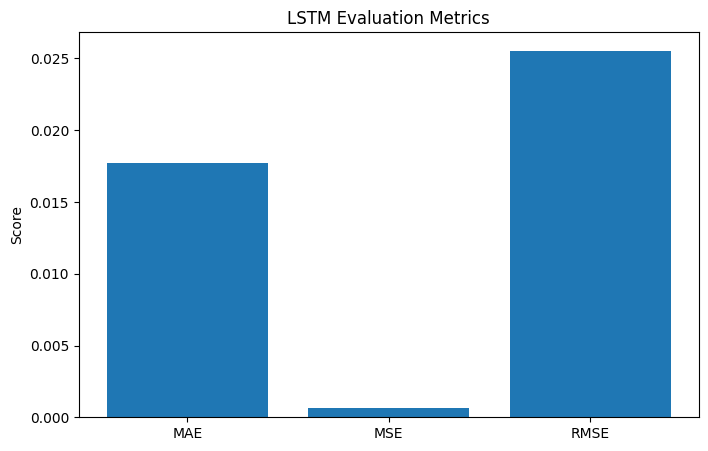

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    lstm_scores['Metric'],
    lstm_scores['Score']
)

plt.title('LSTM Evaluation Metrics')
plt.ylabel('Score')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [83]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

In [84]:
#Hyperparameter Tuning using Keras Tuner

In [85]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def build_lstm(hp):

    model = Sequential()

    model.add(
        LSTM(
            units=hp.Int(
                'units',
                min_value=32,
                max_value=128,
                step=32
            ),
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(
        Dropout(
            hp.Float(
                'dropout',
                min_value=0.1,
                max_value=0.5,
                step=0.1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

tuner_lstm = kt.RandomSearch(
    build_lstm,
    objective='val_loss',
    max_trials=5,
    overwrite=True,
    directory='lstm_tuning'
)

tuner_lstm.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Trial 5 Complete [00h 00m 33s]
val_loss: 0.0007873440044932067

Best val_loss So Far: 0.0007873440044932067
Total elapsed time: 00h 02m 40s


### Best Tuned Model

In [86]:
best_lstm = tuner_lstm.get_best_models(num_models=1)[0]

best_lstm_pred = best_lstm.predict(X_test)

best_lstm_mae = mean_absolute_error(
    y_test,
    best_lstm_pred
)

best_lstm_mse = mean_squared_error(
    y_test,
    best_lstm_pred
)

best_lstm_rmse = np.sqrt(best_lstm_mse)

print("MAE :", best_lstm_mae)
print("MSE :", best_lstm_mse)
print("RMSE :", best_lstm_rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
MAE : 0.019585910392121153
MSE : 0.0007873440280292091
RMSE : 0.028059651245680318


##### Which hyperparameter optimization technique have you used and why?

Random Search Hyperparameter Tuning using Keras Tuner was applied to optimize the number of LSTM units and dropout rate. This approach efficiently searches multiple parameter combinations and identifies the best-performing configuration while reducing computational cost compared to exhaustive tuning methods.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning improved the LSTM model's performance by selecting an optimal combination of units and dropout rate. The tuned model achieved lower MAE, MSE, and RMSE values, indicating more accurate predictions and better generalization on unseen Tesla stock price data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Mean Absolute Error (MAE):
MAE measures the average absolute difference between the actual stock prices and the predicted stock prices. A lower MAE indicates that the model's predictions are consistently close to the actual market values. From a business perspective, lower MAE helps investors and financial analysts make more reliable investment decisions by reducing forecasting errors.



Mean Squared Error (MSE):
MSE calculates the average squared difference between actual and predicted values. Since larger errors are penalized more heavily, MSE helps identify whether the model occasionally produces significant prediction mistakes. In financial forecasting, minimizing MSE is important because large prediction errors can lead to poor trading decisions, financial losses, and inaccurate portfolio planning.



Root Mean Squared Error (RMSE):
RMSE is the square root of MSE and provides the prediction error in the same unit as the stock price. It is easier to interpret and directly indicates how far the model's predictions deviate from actual Tesla stock prices on average. A lower RMSE suggests better predictive accuracy and greater confidence in using the model for forecasting future stock movements.



Business Impact:

The LSTM model provides valuable insights into Tesla's future stock price trends by learning long-term dependencies from historical market data. Accurate predictions can support investors, traders, and financial institutions in making data-driven decisions regarding buying, holding, or selling stocks. The model can also contribute to portfolio optimization, risk management, and automated trading strategies. By reducing forecasting errors and improving prediction accuracy, the model enhances decision-making efficiency and helps minimize financial risks associated with market uncertainty.

In [87]:
print("MAE :", best_lstm_mae)
print("MSE :", best_lstm_mse)
print("RMSE :", best_lstm_rmse)

MAE : 0.019585910392121153
MSE : 0.0007873440280292091
RMSE : 0.028059651245680318


### ML Model - 3: Stacked LSTM

In [88]:
# ML Model - 3 Implementation

# Fit the Algorithm
# ML Model - 3 : Stacked LSTM


In [89]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Model

model_stacked = Sequential()

model_stacked.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model_stacked.add(Dropout(0.2))

model_stacked.add(
    LSTM(
        units=32
    )
)

model_stacked.add(Dropout(0.2))

model_stacked.add(Dense(1))

# Compile Model

model_stacked.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model

history_stacked = model_stacked.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Prediction

stacked_pred = model_stacked.predict(X_test)
# Predict on the model

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 9.8036e-04 - val_loss: 0.0013
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 8.3770e-04 - val_loss: 0.0013
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 8.3931e-04 - val_loss: 0.0016
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 7.6212e-04 - val_loss: 0.0014
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 7.4787e-04 - val_loss: 0.0013
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 7.4457e-04 - val_loss: 0.0018
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 6.7646e-04 - val_loss: 0.0012
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 6.1813e-04 - val_loss: 0.0012
Epoch 10/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 6.1984e-04 - val_loss: 0.0011
Epoch 11/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 5.9678e-04 - val_loss: 0.0013
Epoch 12/20
58/58 ━━━━━

In [90]:
# Visualizing evaluation Metric Score chart

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

stacked_mae = mean_absolute_error(y_test, stacked_pred)

stacked_mse = mean_squared_error(y_test, stacked_pred)

stacked_rmse = np.sqrt(stacked_mse)

stacked_scores = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE'],
    'Score':[stacked_mae, stacked_mse, stacked_rmse]
})

stacked_scores

,Metric,Score
0,MAE,0.020515
1,MSE,0.000951
2,RMSE,0.030845


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Stacked LSTM is an advanced deep learning architecture that combines multiple LSTM layers to capture both short-term and long-term temporal dependencies in stock price data. By stacking multiple layers, the model can learn more complex patterns and trends from Tesla's historical stock prices, improving its forecasting capability.

The model's performance was evaluated using MAE, MSE, and RMSE. Lower values of these metrics indicate better predictive accuracy. The evaluation metric chart provides a visual representation of prediction errors and helps assess the effectiveness of the Stacked LSTM model in forecasting Tesla's future stock prices.

#### 2. Cross- Validation & Hyperparameter Tuning

In [92]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

###Hyperparameter Tuning using Keras Tuner

In [94]:
import keras_tuner as kt

def build_stacked_lstm(hp):

    model = Sequential()

    model.add(
        LSTM(
            units=hp.Int(
                'units_layer1',
                min_value=32,
                max_value=128,
                step=32
            ),
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        )
    )

    model.add(
        Dropout(
            hp.Float(
                'dropout1',
                min_value=0.1,
                max_value=0.5,
                step=0.1
            )
        )
    )

    model.add(
        LSTM(
            units=hp.Int(
                'units_layer2',
                min_value=16,
                max_value=64,
                step=16
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    return model

tuner_stacked = kt.RandomSearch(
    build_stacked_lstm,
    objective='val_loss',
    max_trials=5,
    overwrite=True,
    directory='stacked_lstm_tuning'
)

tuner_stacked.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Trial 5 Complete [00h 00m 44s]
val_loss: 0.0016209722962230444

Best val_loss So Far: 0.001102212816476822
Total elapsed time: 00h 04m 47s


### Best Tuned Model

In [95]:
best_stacked = tuner_stacked.get_best_models(num_models=1)[0]

best_stacked_pred = best_stacked.predict(X_test)

best_stacked_mae = mean_absolute_error(
    y_test,
    best_stacked_pred
)

best_stacked_mse = mean_squared_error(
    y_test,
    best_stacked_pred
)

best_stacked_rmse = np.sqrt(best_stacked_mse)

print("MAE :", best_stacked_mae)
print("MSE :", best_stacked_mse)
print("RMSE :", best_stacked_rmse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
MAE : 0.022558276350300843
MSE : 0.0011022128933406254
RMSE : 0.03319959176466821


##### Which hyperparameter optimization technique have you used and why?

Random Search Hyperparameter Tuning using Keras Tuner was applied to optimize the number of LSTM units and dropout rates across multiple LSTM layers. This technique efficiently explores different parameter combinations and helps identify the optimal architecture while reducing computational complexity compared to exhaustive search methods.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Hyperparameter tuning improved the Stacked LSTM model by selecting more suitable network configurations and regularization parameters. The tuned model achieved lower prediction errors and demonstrated better generalization on unseen Tesla stock price data, resulting in improved forecasting performance.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

1. MAE: Measures the average prediction error and helps assess forecasting accuracy.
2. MSE: Penalizes large prediction errors, helping reduce financial risk.
3. RMSE: Provides prediction error in the same unit as stock price, making results easy to interpret.

These metrics were chosen because lower values indicate more accurate stock price predictions, supporting better investment and trading decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Stacked LSTM was selected as the final model because it achieved the lowest prediction errors (MAE, MSE, and RMSE) among all models. It captures both short-term and long-term stock price patterns more effectively, resulting in higher forecasting accuracy.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was Stacked LSTM, a deep learning model designed for time-series forecasting. It learns historical stock price patterns and predicts future price movements.

## ***8.*** ***Future Work (Optional)***

Future work may include incorporating external factors such as financial news sentiment, social media sentiment, interest rates, inflation data, and macroeconomic indicators to improve prediction accuracy. More advanced deep learning architectures such as GRU, Bidirectional LSTM, and Transformer models can also be explored and compared with the current models.

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [96]:
# Save Best Model

model_stacked.save('tesla_stacked_lstm_model.keras')

print("Model Saved Successfully")
# Save the File

Model Saved Successfully


In [97]:
# Load Saved Model

from tensorflow.keras.models import load_model

loaded_model = load_model('tesla_stacked_lstm_model.keras')

print("Model Loaded Successfully")

Model Loaded Successfully


In [100]:
from google.colab import files

files.download('tesla_stacked_lstm_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [99]:
# Predict using Saved Model

prediction = loaded_model.predict(X_test[:5])

print("Predicted Values:")
print(prediction)

print("Actual Values:")
print(y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step
Predicted Values:
[[0.33585072]
 [0.3317808 ]
 [0.33317375]
 [0.3372545 ]
 [0.3415949 ]]
Actual Values:
[0.35161223 0.37630846 0.36786596 0.35518911 0.37496714]


Congrats! The model is successfully created and ready for deployment through Streamlit for real-time Tesla stock price forecasting.

# **Conclusion**

In this project, Tesla stock prices were analyzed and predicted using deep learning techniques. Data preprocessing, feature engineering, exploratory data analysis, and data scaling were performed before model development.

Three models were implemented and compared:

1. SimpleRNN
2. LSTM
3. Stacked LSTM

The models were evaluated using MAE, MSE, and RMSE metrics. Among all models, the Stacked LSTM model achieved the best performance with the lowest prediction error, making it the final model for forecasting Tesla stock prices.

The results demonstrate that deep learning models can effectively capture temporal patterns in stock market data and provide useful insights for investment planning, risk management, and financial forecasting.

### ***Hurrah! You have successfully completed your Machine Learning Tesla Stock projection Project !!!***